# (3) TITLE:            Given temporally (not spatially) averaged climate values for a region, get the mean and standard deviation among pixels in the region, combining future and present into one .csv file. 
PROJECT:          "Climate analogs under SAI"  
AUTHORS:          Ruoyu Chen  
COLLABORATORS:    
DATA INPUT:       The .nc output files from `code_to_avg_files.ipynb`. These are the temporal and ensemble average over a selected period for climate variables (TSMX, PRECT, SST...) for the 3 climate scenarios. Saved in `"/mnt/research/nasabio/data/climate/L1/present"` for present period and `"/mnt/research/nasabio/data/climate/L1/future"` for future period.
                   
DATA OUTPUT:      Final output is a .csv file, which contains climate variables averaged over the specific location (region, point, or buffered point). Saved in `/mnt/research/nasabio/data/climate/L1/avg_csv_output`.   
DATE:             Initiated: 5 June 2026; last run: ____  
OVERVIEW:         Root path is: "/mnt/research/nasabio/data/climate/L1". First function, `get_location_data_all_pixels`, clips the data from the data input, and `add_mean_to_dataframe` takes the mean of the cropped region and saves it in a file.  
REQUIRES:         .nc files of the temporally averaged output from `code_to_avg_files.ipynb`.  
NOTES:            Code files #2. 

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import geopandas as gpd
import earthpy as et
import xarray as xr
# Spatial subsetting of netcdf files
import regionmask
import rioxarray


import pyproj
from shapely.ops import transform
from shapely.geometry import Point
import glob
from csv import writer


# Plotting options
sns.set(font_scale=1.3)
sns.set_style("white")


import warnings
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning
)

import earthpy as et

# This is the function get_location_data_all_pixels from all_data_for_location.ipynb
# We need to use this function because it actually returns a list of xarray Datasets, 
# one Dataset for each climate scenario (SSP245, SAI-1.0, SAI-1.5) and for each climate variable (TSMX, PRECT, SST...) 
# clipped around a region, point, or buffered point, and a timeframe.  
# We need to use this to get two lists, one list for all the present variables of a location, 
# and one list for all the future variables of a location. 

# This way, we can input to `add_stats_to_dataframe` with all the pixel climate data it needs to calculate
# mean and standard deviation (or more)
from helper_function_get_location_data_all_pixels import convert_longitude, get_location_data_all_pixels


/mnt/home/f0113797/.conda/envs/testgeo4/lib/python3.14/site-packages/earthpy/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


## `add_stats_to_dataframe` ReadMe: 
Gets the mean and standard deviation across the pixels in a given region for the future and present for all climate variables. 
Important! Since the input to this was based on different climate variables for the same scenario and same timeframe, we have multiple associated with the same time/scenario. This means that we need to merge them into one line, which is what this does: 
```
    merged_output_df = output_df.groupby(["location", "scenario", "timeframe"], as_index=False).first()  
```  
Without this line of code, there will be many gaps in the .csv file.   
Ouptut saved in `/mnt/research/nasabio/data/climate/L1/scenario_comparisons`. Rows are differentiated by scenario, timeframe, and location.    

Input: 
* `all_list`: `list` of Xarray `Datasets`. Each `Dataset` should have a climate scenario (SSP245, SAI-1.0, SAI-1.5), climate variable (PRECT, TSMX, SST...), and timeframe (2015-2034, or 2050-2069). This list should include both present and future timeframes. 
* `location_name`: `String` of the location name (for shapefile, buffered point, etc). 
* `output_path`: `String` of the output path, including the file name you want to save it to. 
* `new_file`: `boolean`. True if you want to make a new .csv file, False if you want to add data to an existing dataset. 

In [2]:
def add_stats_to_dataframe(all_list, location_name, output_path, new_file):
    output_dic = []
    
    for scenario in all_list: 
        scen_row = {
            "location": location_name, 
            "scenario" : scenario.scenario,
            "timeframe": (scenario.title_description)[-9:]
        }
        
        data_vars = list(scenario.data_vars)
        for var in data_vars: 
            mean_of_var = np.nanmean(scenario[var].values)
            scen_row[scenario.variable + "_" + var + "_cell_avgs"] = mean_of_var
            
            st_of_var = np.nanstd(scenario[var].values)
            scen_row[scenario.variable + "_" + var + "_cell_st"] = st_of_var
        
        output_dic.append(scen_row)

    output_df = pd.DataFrame(output_dic)
    merged_output_df = output_df.groupby(["location", "scenario", "timeframe"], as_index=False).first()  
    
    if (new_file): 
        merged_output_df.to_csv(output_path, index=False) #This is creating a new .csv file. 
    else: 
        merged_output_df.to_csv(output_path, mode='a', index=False, header=False)

### Example of saving comparison data across pixels of one region (average and standard deviation)
The following cell calls `get_location_data_all_pixels` imported from `helper_function_get_location_data_all_pixels.py` twice, once for the future, and once for the present, to get the full data for every pixel at the East Lansing location for add_stats_to_dataframe, and saves it to `"/mnt/research/nasabio/data/climate/L1/scenario_comparisons/test3.csv"`. 

In [5]:
el_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", buffer = 500000, target_lat = 42.7370, target_lon = -84.4839) #East lansing
el_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", buffer = 500000, target_lat = 42.7370, target_lon = -84.4839) #East lansing
el_all = el_p + el_f

add_stats_to_dataframe(el_all, "East Lansing", "/mnt/research/nasabio/data/climate/L1/scenario_comparisons/test3.csv", True)

### Getting absolute and relative differences at a location across future scenarios. 

In [75]:
# Getting the ABSOLUTE change for temperature. 
dataframe = pd.read_csv("/mnt/research/nasabio/data/climate/L1/scenario_comparisons/test2.csv")
data_variable = 'TSMX_annual_mean_cell_avgs'


location_df = dataframe.loc[dataframe["location"] == "Southern Plains",
     ["scenario", "timeframe", data_variable]]
print(location_df)
present_SSP_val = location_df.loc[(location_df["timeframe"] == "2015-2034"), data_variable]
present_val = present_SSP_val.iloc[0]
print("Present value: " + str(present_val))


future_SAI10_val = location_df.loc[(location_df["scenario"] == "ARISE_SAI_1p0"), data_variable].iloc[0]
future_SAI15_val = location_df.loc[(location_df["scenario"] == "ARISE_SAI_1p5"), data_variable].iloc[0]
future_SSP_val = location_df.loc[(location_df["scenario"] == "SSP245") & (location_df["timeframe"] == "2050-2069"), data_variable].iloc[0]
dict_future = {
    "future_SAI10_val" : float(future_SAI10_val), 
    "future_SAI15_val" : float(future_SAI15_val), 
    "future_SSP_val" : float(future_SSP_val)
}
print("Future values: " + str(dict_future))
print()

diff_SAI10_val = future_SAI10_val - present_val
diff_SAI15_val = future_SAI15_val - present_val
diff_SSP_val = future_SSP_val - present_val
print("This is the absolute difference between the present period and 3 future scenarios for variable " + data_variable)
print("Absolute difference of SAI 1.0: " + str(diff_SAI10_val))
print("Absolute difference of SAI 1.5: " + str(diff_SAI15_val))
print("Absolute difference of SSP2 4.5: " + str(diff_SSP_val))



        scenario  timeframe  TSMX_annual_mean_cell_avgs
0  ARISE_SAI_1p0  2050-2069                   32.993359
1  ARISE_SAI_1p5  2050-2069                   33.765701
2         SSP245  2015-2034                   33.748917
3         SSP245  2050-2069                   34.837673
Present value: 33.74891662597656
Future values: {'future_SAI10_val': 32.99335861206055, 'future_SAI15_val': 33.76570129394531, 'future_SSP_val': 34.83767318725586}

This is the absolute difference between the present period and 3 future scenarios for variable TSMX_annual_mean_cell_avgs
Absolute difference of SAI 1.0: -0.7555580139160156
Absolute difference of SAI 1.5: 0.01678466796875
Absolute difference of SSP2 4.5: 1.0887565612792969


In [74]:
# Getting the RELATIVE change for other variables. 
dataframe = pd.read_csv("/mnt/research/nasabio/data/climate/L1/scenario_comparisons/test2.csv")
data_variable = 'PRECT_CDD_cell_avgs'


location_df = dataframe.loc[dataframe["location"] == "Southern Plains",
     ["scenario", "timeframe", data_variable]]
print(location_df)
present_SSP_val = location_df.loc[(location_df["timeframe"] == "2015-2034"), data_variable]
present_val = present_SSP_val.iloc[0]
print("Present value: " + str(present_val))


future_SAI10_val = location_df.loc[(location_df["scenario"] == "ARISE_SAI_1p0"), data_variable].iloc[0]
future_SAI15_val = location_df.loc[(location_df["scenario"] == "ARISE_SAI_1p5"), data_variable].iloc[0]
future_SSP_val = location_df.loc[(location_df["scenario"] == "SSP245") & (location_df["timeframe"] == "2050-2069"), data_variable].iloc[0]
dict_future = {
    "future_SAI10_val" : float(future_SAI10_val), 
    "future_SAI15_val" : float(future_SAI15_val), 
    "future_SSP_val" : float(future_SSP_val)
}
print("Future values: " + str(dict_future))

print()
diff_SAI10_val = (future_SAI10_val - present_val) / present_val
diff_SAI15_val = (future_SAI15_val - present_val) / present_val
diff_SSP_val = (future_SSP_val - present_val) / present_val
print("This is the absolute difference between the present period and 3 future scenarios for variable " + data_variable)
print("Relative change of SAI 1.0: " + str(diff_SAI10_val * 100) + "%")
print("Relative change of SAI 1.5: " + str(diff_SAI15_val * 100) + "%")
print("Relative change of SSP2 4.5: " + str(diff_SSP_val * 100) + "%")



        scenario  timeframe  PRECT_CDD_cell_avgs
0  ARISE_SAI_1p0  2050-2069            34.809040
1  ARISE_SAI_1p5  2050-2069            34.011383
2         SSP245  2015-2034            36.217388
3         SSP245  2050-2069            35.022152
Present value: 36.21738815307617
Future values: {'future_SAI10_val': 34.80904006958008, 'future_SAI15_val': 34.011383056640625, 'future_SSP_val': 35.022151947021484}

This is the absolute difference between the present period and 3 future scenarios for variable PRECT_CDD_cell_avgs
Relative change of SAI 1.0: -3.8885964872551804%
Relative change of SAI 1.5: -6.091011000328518%
Relative change of SSP2 4.5: -3.300172284657607%


# TESTING BELOW, IGNORE!

In [ ]:
#from all_data_for_location.ipynb import get_location_data_all_pixels
from ipynb.fs.full.all_data_for_location import get_location_data_all_pixels

path_present = "/mnt/research/nasabio/data/climate/L1/present/SSP245_TSMX_extreme_high.nc"
path_SAI10 = "/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p0_TSMX_extreme_high.nc"
path_SAI15 = "/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p5_TSMX_extreme_high.nc"
path_SSP245 = "/mnt/research/nasabio/data/climate/L1/future/SSP245_TSMX_extreme_high.nc"

def compare_scenarios_avg(climate_variable_title, path_file, *, shapefile = None, target_lat = None, target_lon = None, buffer = None):
    scenarios = ["ARISE_SAI_1p0_", "ARISE_SAI_1p5_", "SSP245_"]
    avg_datasets = {}
    for each in scenarios: 
        avg_dataset = xr.open_dataset(path_file + "/" + each + "_" + climate_variable_title + ".nc")



for each in temp_netcdf:
    mean_of_var = np.nanmean(each["annual_mean"].values)
    print(mean_of_var)
    
    plt.figure(figsize = (7,5))
    each["annual_mean"].plot()
    plt.show()
    

In [ ]:
path_SAI10 = "/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p0_TSMX_extreme_high.nc"
path_SAI15 = "/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p5_TSMX_extreme_high.nc"
path_SSP245 = "/mnt/research/nasabio/data/climate/L1/future/SSP245_TSMX_extreme_high.nc"

temp_netcdf = [xr.open_dataset(path_SAI10), xr.open_dataset(path_SAI15), xr.open_dataset(path_SSP245)]


mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)
mid_atl = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]


for each in temp_netcdf:
    mask = regionmask.mask_geopandas(mid_atl, each.lon, each.lat)
    sliced_masked = each.where(mask.notnull(), drop=True)

    mean_of_var = np.nanmean(each["annual_mean"].values)
    print(mean_of_var)
    
    plt.figure(figsize = (7,5))

    sliced_masked["annual_mean"].plot(vmin = 20, vmax = 31)
    plt.show()

### This was for Midsure plots.

In [5]:
x_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", buffer = 30000, target_lat = 42.7370, target_lon = -84.4839) #East lansing
p_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", buffer = 30000, target_lat = 39.952583, target_lon = -75.165222) #Philly

mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)

great_lakes = NEON_sites[NEON_sites.domainName == "Great Lakes"]
gl_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", shapefile = great_lakes)

mid_atlantic = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]
ma_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", shapefile = mid_atlantic)
x_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", buffer = 30000, target_lat = 42.7370, target_lon = -84.4839) #East lansing
p_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", buffer = 30000, target_lat = 39.952583, target_lon = -75.165222) #Philly
gl_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", shapefile = great_lakes)
ma_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", shapefile = mid_atlantic)


In [8]:
x_a = x_p + x_f
add_stats_to_dataframe(x_a, "East Lansing", "/mnt/research/nasabio/data/climate/L1/scenario_comparisons/midsure_elpmagl.csv", True)

p_a = p_p + p_f
add_stats_to_dataframe(p_a, "Philadelphia", "/mnt/research/nasabio/data/climate/L1/scenario_comparisons/midsure_elpmagl.csv", False)

gl_a = gl_p + gl_f
add_stats_to_dataframe(gl_a, "Great Lakes", "/mnt/research/nasabio/data/climate/L1/scenario_comparisons/midsure_elpmagl.csv", False)

ma_a = ma_p + ma_f
add_stats_to_dataframe(ma_a, "Mid Atlantic", "/mnt/research/nasabio/data/climate/L1/scenario_comparisons/midsure_elpmagl.csv", False)


In [ ]:
mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)
mid_atlantic = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]
gl_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", shapefile = great_lakes)
gl_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", shapefile = great_lakes)


In [28]:
mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)
great_lakes = NEON_sites[NEON_sites.domainName == "Great Lakes"]
ma_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", shapefile = mid_atlantic)
ma_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", shapefile = mid_atlantic)


In [4]:
gl_a = gl_p + gl_f
add_stats_to_dataframe(gl_a, "Great Lakes", "/mnt/research/nasabio/data/climate/L1/scenario_comparisons/great_lakes.csv", True)

In [24]:
gl_p_temp = gl_p[0]
gl_f_temp = [gl_f[0], gl_f[1], gl_f[4]]
gl_diff = [gl_f[0] - gl_p[0], gl_f[1] - gl_p[0], gl_f[4] - gl_p[0]]

gl_p_temp
sai10_diff = gl_diff[0]
sai15_diff = gl_diff[2]
ssp245_diff = gl_diff[1]

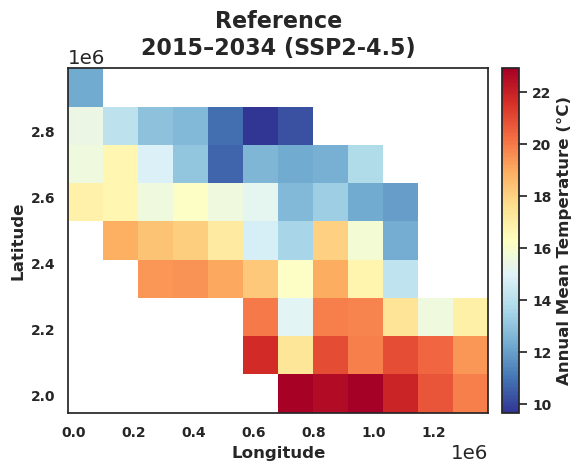

In [36]:
# Assign datasets
sai10_diff = gl_diff[0]
ssp245_diff = gl_diff[1]
sai15_diff = gl_diff[2]

# Select annual mean variables
reference = gl_p_temp["annual_mean"]

ssp245 = ssp245_diff["annual_mean"]
sai15 = sai15_diff["annual_mean"]
sai10 = sai10_diff["annual_mean"]


# Absolute minimum and maximum for the reference dataset

ref_vmin = float(reference.min(skipna=True))
ref_vmax = float(reference.max(skipna=True))

fig, ax = plt.subplots(figsize=(6.1, 5))

ref_image = reference.plot(
    ax=ax,
    cmap="RdYlBu_r",
    vmin=ref_vmin,
    vmax=ref_vmax,
    add_colorbar=False
)

ax.set_title(
    "Reference\n2015–2034 (SSP2-4.5)",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax.set_xlabel(
    "Longitude",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Latitude",
    fontsize=12,
    fontweight="bold"
)

# Bold axis tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

# Reference colorbar
ref_cbar = fig.colorbar(
    ref_image,
    ax=ax,
    fraction=0.046,
    pad=0.03
)

ref_cbar.set_label(
    "Annual Mean Temperature (°C)",
    fontsize=12,
    fontweight="bold"
)

for label in ref_cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

plt.tight_layout()
plt.show()

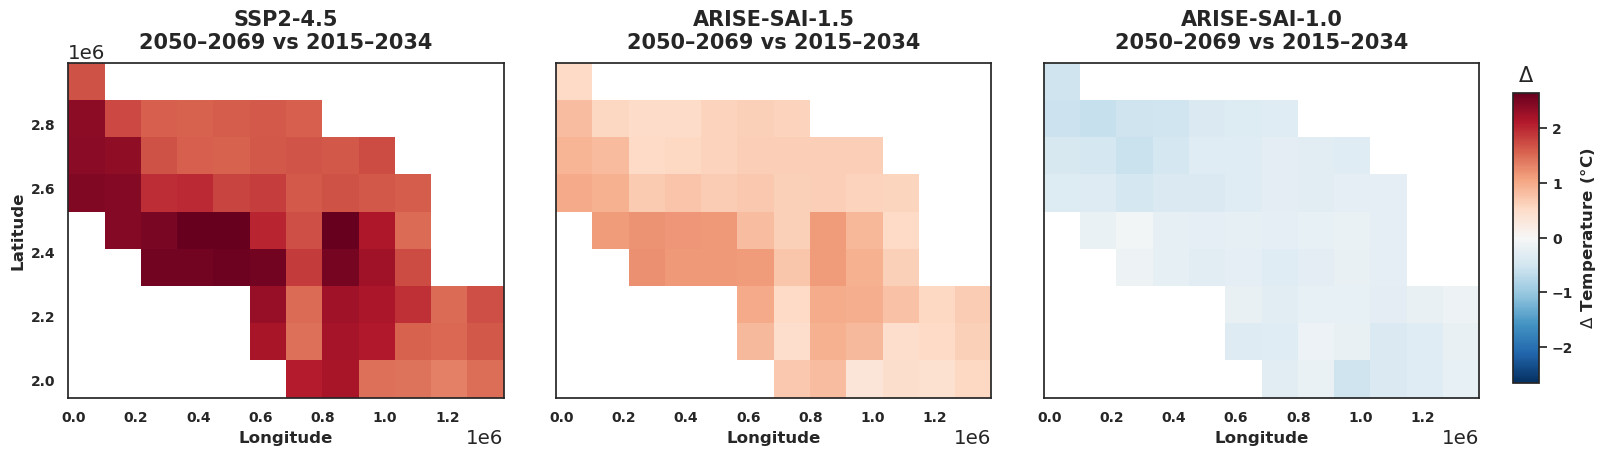

In [37]:
# Assign datasets
sai10_diff = gl_diff[0]
ssp245_diff = gl_diff[1]
sai15_diff = gl_diff[2]

# Select annual mean variables
reference = gl_p_temp["annual_mean"]

ssp245 = ssp245_diff["annual_mean"]
sai15 = sai15_diff["annual_mean"]
sai10 = sai10_diff["annual_mean"]


future_data = [
    ssp245,
    sai15,
    sai10
]

future_titles = [
    "SSP2-4.5\n2050–2069 vs 2015–2034",
    "ARISE-SAI-1.5\n2050–2069 vs 2015–2034",
    "ARISE-SAI-1.0\n2050–2069 vs 2015–2034"
]

# Shared symmetric color scale centered at zero
delta_max = max(
    float(np.abs(d).max(skipna=True))
    for d in future_data
)

delta_vmin = -delta_max
delta_vmax = delta_max

fig, axs = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    sharex=True,
    sharey=True
)

for ax, d, title in zip(axs, future_data, future_titles):
    delta_image = d.plot(
        ax=ax,
        cmap="RdBu_r",
        vmin=delta_vmin,
        vmax=delta_vmax,
        add_colorbar=False
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel(
        "Longitude",
        fontsize=12,
        fontweight="bold"
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontsize(10)

axs[0].set_ylabel(
    "Latitude",
    fontsize=12,
    fontweight="bold"
)

axs[1].set_ylabel("")
axs[2].set_ylabel("")

# Make room on the right for one shared colorbar
fig.subplots_adjust(
    left=0.07,
    right=0.90,
    bottom=0.15,
    top=0.82,
    wspace=0.12
)

# Shared future colorbar
cbar_ax = fig.add_axes([
    0.92,
    0.18,
    0.015,
    0.58
])

delta_cbar = fig.colorbar(
    delta_image,
    cax=cbar_ax
)

delta_cbar.ax.set_title(
    r"$\Delta$",
    fontsize=15,
    fontweight="bold",
    pad=8
)

delta_cbar.set_label(
    r"$\Delta$ Temperature (°C)",
    fontsize=12,
    fontweight="bold"
)

for label in delta_cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

plt.show()

In [36]:
gl_diff[0]

<xarray.Dataset> Size: 3kB
Dimensions:         (x: 12, y: 9)
Coordinates:
  * x               (x) float64 96B 4.081e+04 1.574e+05 ... 1.207e+06 1.323e+06
  * y               (y) float64 72B 2.932e+06 2.816e+06 ... 2.121e+06 2.005e+06
    spatial_ref     int64 8B 0
Data variables:
    annual_mean     (y, x) float32 432B -0.5568 nan nan ... -0.3146 -0.2108
    frequency       (y, x) float64 864B -0.83 nan nan nan ... -1.1 -1.06 -0.83
    duration        (y, x) float64 864B -0.06237 nan nan ... 0.07416 0.07408
    mean_intensity  (y, x) float32 432B -1.676 nan nan ... -0.8713 -0.33 -0.2747
    max_intensity   (y, x) float32 432B -1.134 nan nan ... -1.869 -2.137 -2.145
Attributes:
    variable:               TSMX
    member:                 006
    event_type:             extreme_high
    season:                 annual
    clim_reference:         SSP245 2015-2034
    consec_days_threshold:  3
    extreme_direction:      above
    quantile:               0.9
    land_mask:              Natural Earth 110m
    threshold_method:       pooled individual members, linear detrend

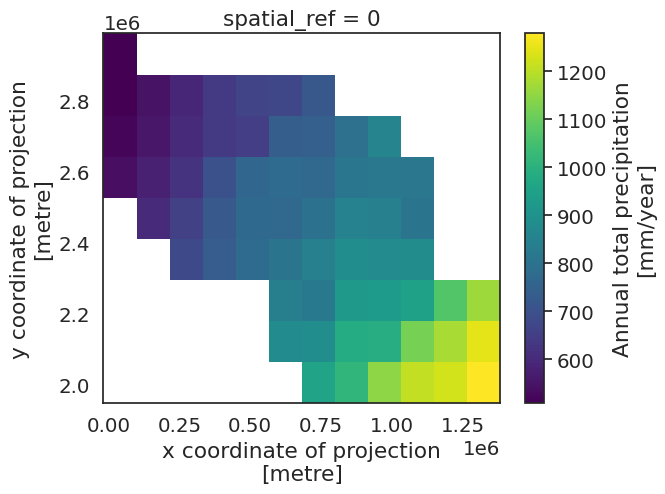

In [19]:
gl_p[1]["PRCPTOT"].plot()

In [ ]:
mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)
mid_atlantic = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]

ma_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", shapefile = mid_atlantic)
ma_f = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", shapefile = mid_atlantic)

ma_a = ma_p + ma_f
add_stats_to_dataframe(ma_a, "Mid Atlantic", "/mnt/research/nasabio/data/climate/L1/scenario_comparisons/mid_atlantic.csv", True)


In [42]:
ma_p_temp = ma_p[0]
ma_diff = [ma_f[0] - ma_p[0], ma_f[1] - ma_p[0], ma_f[4] - ma_p[0]]

sai10_diff = ma_diff[0]
sai15_diff = ma_diff[2]
ssp245_diff = ma_diff[1]

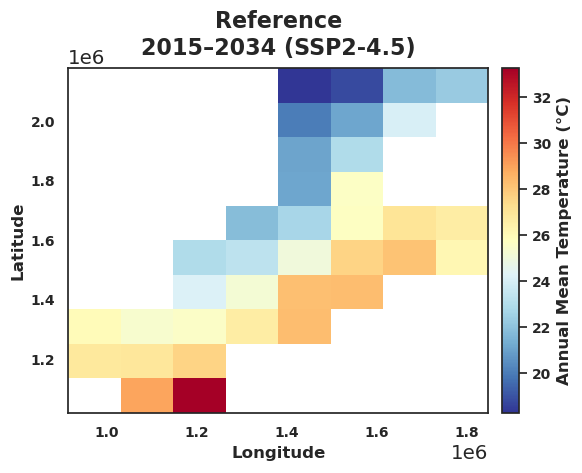

In [43]:
# Select annual mean variables
reference = ma_p_temp["annual_mean"]

ssp245 = ssp245_diff["annual_mean"]
sai15 = sai15_diff["annual_mean"]
sai10 = sai10_diff["annual_mean"]


# Absolute minimum and maximum for the reference dataset

ref_vmin = float(reference.min(skipna=True))
ref_vmax = float(reference.max(skipna=True))

fig, ax = plt.subplots(figsize=(6.1, 5))

ref_image = reference.plot(
    ax=ax,
    cmap="RdYlBu_r",
    vmin=ref_vmin,
    vmax=ref_vmax,
    add_colorbar=False
)

ax.set_title(
    "Reference\n2015–2034 (SSP2-4.5)",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax.set_xlabel(
    "Longitude",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Latitude",
    fontsize=12,
    fontweight="bold"
)

# Bold axis tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

# Reference colorbar
ref_cbar = fig.colorbar(
    ref_image,
    ax=ax,
    fraction=0.046,
    pad=0.03
)

ref_cbar.set_label(
    "Annual Mean Temperature (°C)",
    fontsize=12,
    fontweight="bold"
)

for label in ref_cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

plt.tight_layout()
plt.show()

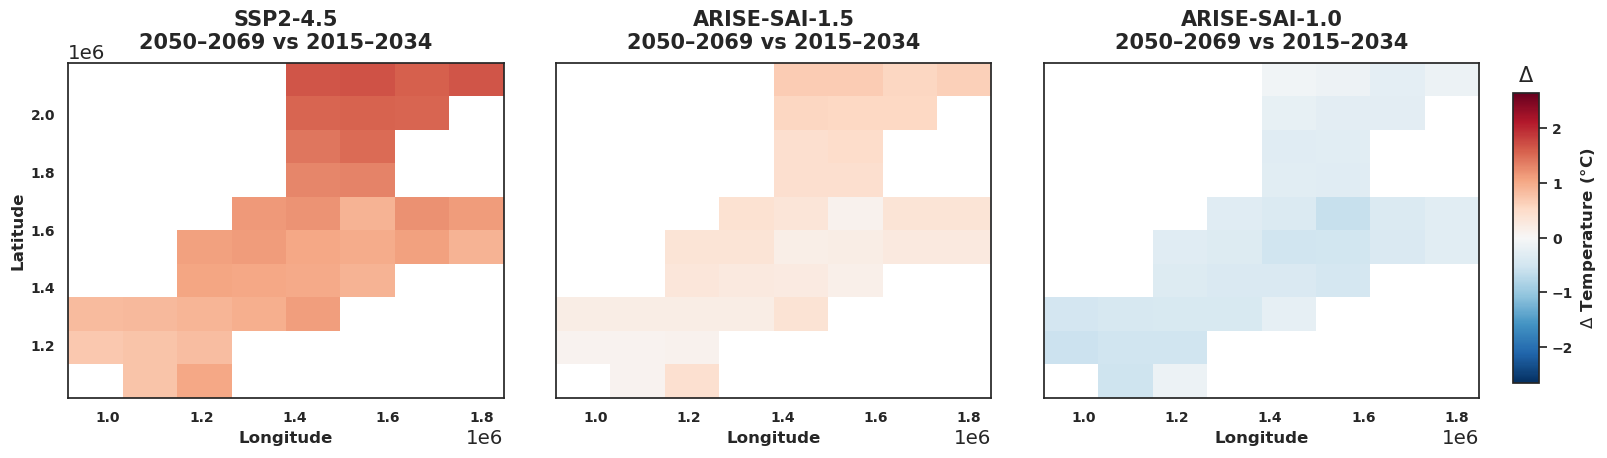

In [44]:


future_data = [
    ssp245,
    sai15,
    sai10
]

future_titles = [
    "SSP2-4.5\n2050–2069 vs 2015–2034",
    "ARISE-SAI-1.5\n2050–2069 vs 2015–2034",
    "ARISE-SAI-1.0\n2050–2069 vs 2015–2034"
]

# Shared symmetric color scale centered at zero
delta_max = max(
    float(np.abs(d).max(skipna=True))
    for d in future_data
)


fig, axs = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    sharex=True,
    sharey=True
)

for ax, d, title in zip(axs, future_data, future_titles):
    delta_image = d.plot(
        ax=ax,
        cmap="RdBu_r",
        vmin=delta_vmin,
        vmax=delta_vmax,
        add_colorbar=False
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel(
        "Longitude",
        fontsize=12,
        fontweight="bold"
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontsize(10)

axs[0].set_ylabel(
    "Latitude",
    fontsize=12,
    fontweight="bold"
)

axs[1].set_ylabel("")
axs[2].set_ylabel("")

# Make room on the right for one shared colorbar
fig.subplots_adjust(
    left=0.07,
    right=0.90,
    bottom=0.15,
    top=0.82,
    wspace=0.12
)

# Shared future colorbar
cbar_ax = fig.add_axes([
    0.92,
    0.18,
    0.015,
    0.58
])

delta_cbar = fig.colorbar(
    delta_image,
    cax=cbar_ax
)

delta_cbar.ax.set_title(
    r"$\Delta$",
    fontsize=15,
    fontweight="bold",
    pad=8
)

delta_cbar.set_label(
    r"$\Delta$ Temperature (°C)",
    fontsize=12,
    fontweight="bold"
)

for label in delta_cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

plt.show()

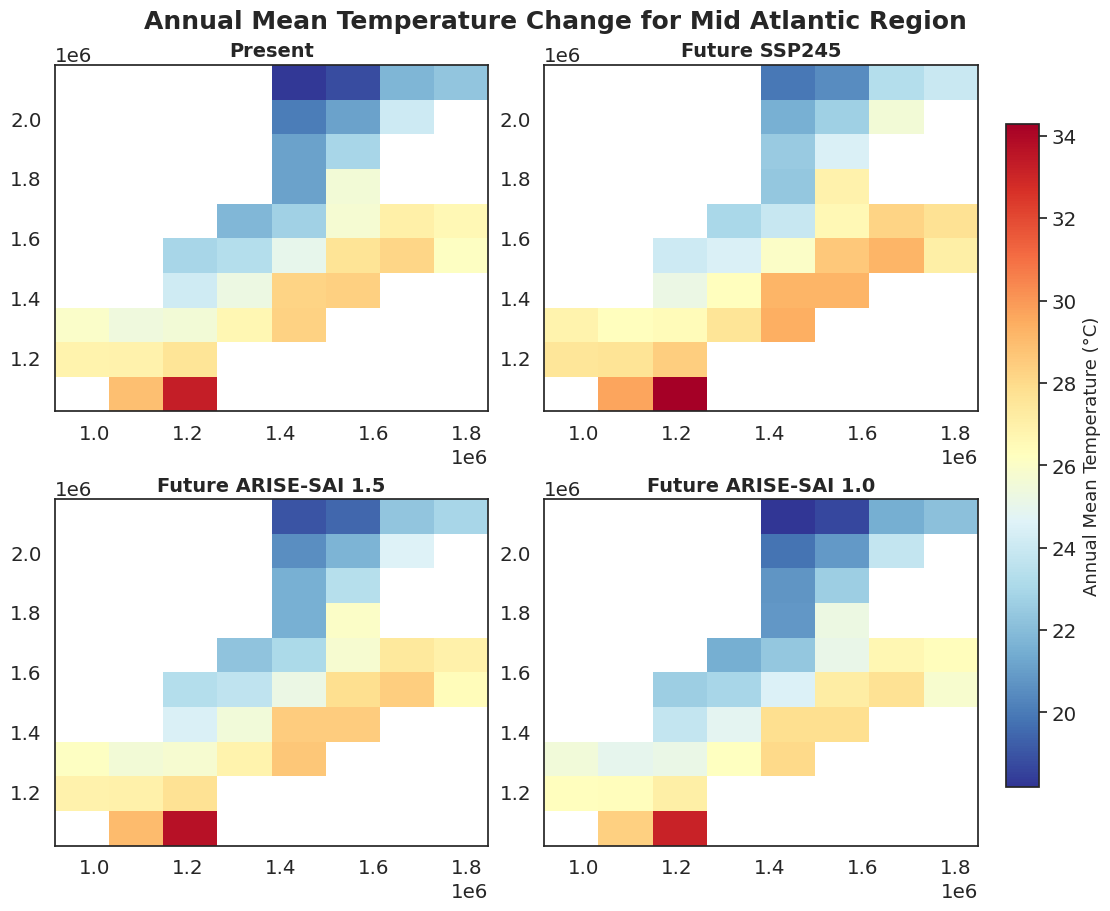

In [5]:
data = [
    ma_a[0]["annual_mean"],
    ma_a[3]["annual_mean"],
    ma_a[-2]["annual_mean"],
    ma_a[2]["annual_mean"]
]

titles = [
    "Present",
    "Future SSP245",
    "Future ARISE-SAI 1.5",
    "Future ARISE-SAI 1.0"
]

# Choose a narrower temperature range
vmin = min(float(d.min()) for d in data)
vmax = max(float(d.max()) for d in data)

fig, axs = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)

for ax, d, title in zip(axs.flat, data, titles):
    d.plot(
        ax=ax,
        cmap="RdYlBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

# Overall figure title
fig.suptitle(
    "Annual Mean Temperature Change for Mid Atlantic Region",
    fontsize=18,
    fontweight="bold"
)

# Shared colorbar
cbar = fig.colorbar(
    axs[0,0].collections[0],
    ax=axs,
    shrink=0.85,
    pad=0.03
)
cbar.set_label("Annual Mean Temperature (°C)", fontsize=13)

plt.show()

In [14]:
print(ma_a[0]["annual_mean"])

<xarray.DataArray 'annual_mean' (y: 10, x: 8)> Size: 320B
array([[      nan,       nan,       nan,       nan, 18.27701 , 18.776535,
        21.747568, 22.296429],
       [      nan,       nan,       nan,       nan, 20.015545, 21.132675,
        24.063137,       nan],
       [      nan,       nan,       nan,       nan, 21.083054, 22.913294,
              nan,       nan],
       [      nan,       nan,       nan,       nan, 21.09818 , 25.606985,
              nan,       nan],
       [      nan,       nan,       nan, 21.819921, 22.724411, 25.68159 ,
        27.014599, 26.620798],
       [      nan,       nan, 22.948217, 23.299814, 25.029696, 27.633322,
        28.147238, 26.161947],
       [      nan,       nan, 24.143534, 25.238407, 28.238285, 28.339676,
              nan,       nan],
       [25.972742, 25.394962, 25.584158, 26.642242, 28.293528,       nan,
              nan,       nan],
       [26.828598, 26.888302, 27.60786 ,       nan,       nan,       nan,
              nan,       nan

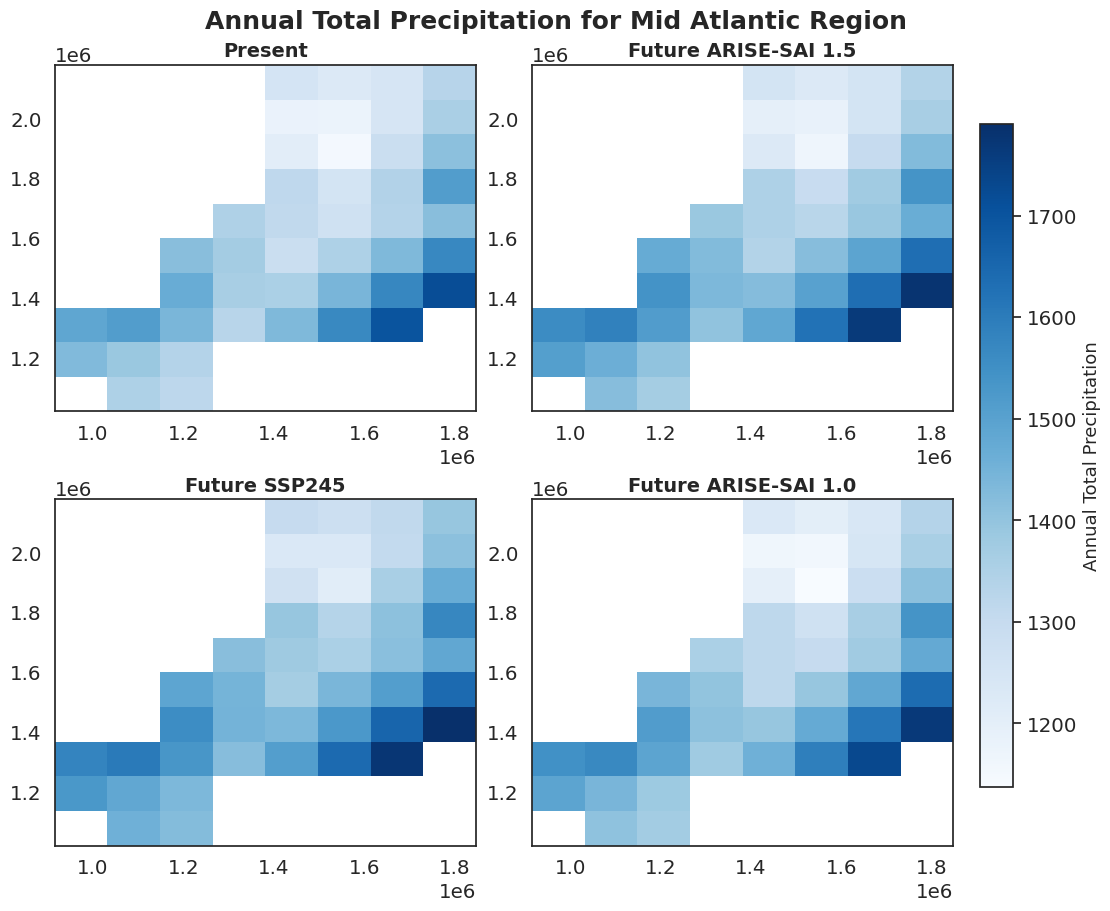

In [12]:
data = [
    ma_a[1]["PRCPTOT"],
    ma_a[4]["PRCPTOT"],
    ma_a[5]["PRCPTOT"],
    ma_a[7]["PRCPTOT"]
]

titles = [
    "Present",
    "Future ARISE-SAI 1.5",
    "Future SSP245",
    "Future ARISE-SAI 1.0"
]

# Determine a common precipitation color scale
vmin = min(float(d.min()) for d in data)
vmax = max(float(d.max()) for d in data)

fig, axs = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)

for ax, d, title in zip(axs.flat, data, titles):
    d.plot(
        ax=ax,
        cmap="Blues",          # Better colormap for precipitation
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle(
    "Annual Total Precipitation for Mid Atlantic Region",
    fontsize=18,
    fontweight="bold"
)

cbar = fig.colorbar(
    axs[0,0].collections[0],
    ax=axs,
    shrink=0.85,
    pad=0.03
)
cbar.set_label("Annual Total Precipitation", fontsize=13)

plt.show()

Shared color range: -52.24 to 50.36 °C


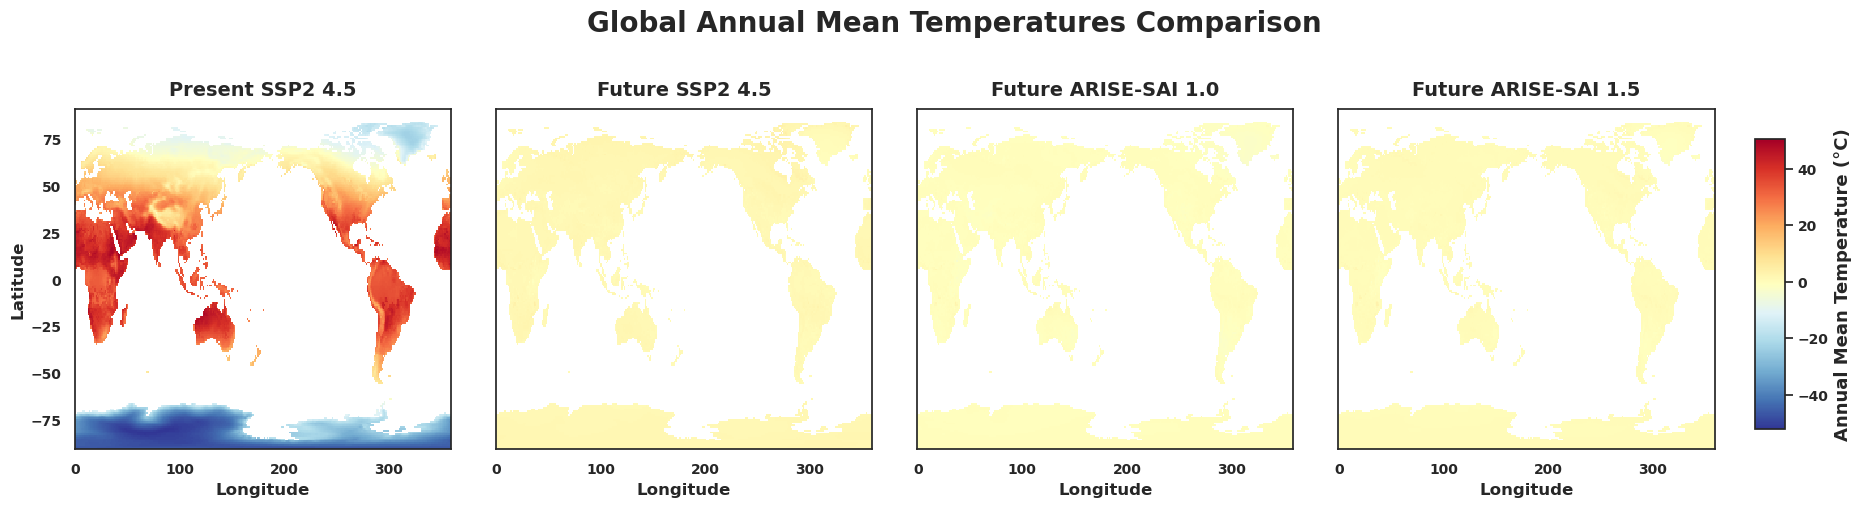

In [11]:
pres = xr.open_dataset("/mnt/research/nasabio/data/climate/L1/present/SSP245_TSMX_extreme_high.nc")
futssp = xr.open_dataset("/mnt/research/nasabio/data/climate/L1/future/SSP245_TSMX_extreme_high.nc")
futsai1 = xr.open_dataset("/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p0_TSMX_extreme_high.nc")
futsai15 = xr.open_dataset("/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p5_TSMX_extreme_high.nc")

futssp = futssp - pres
futsai1 = futsai1 - pres
futsai15 = futsai15 - pres

data = [
    pres["annual_mean"],
    futssp["annual_mean"],
    futsai1["annual_mean"],
    futsai15["annual_mean"]
]

titles = [
    "Present SSP2 4.5",
    "Future SSP2 4.5",
    "Future ARISE-SAI 1.0",
    "Future ARISE-SAI 1.5"
]

# Absolute minimum and maximum across all four datasets
vmin = min(float(d.min(skipna=True)) for d in data)
vmax = max(float(d.max(skipna=True)) for d in data)

print(f"Shared color range: {vmin:.2f} to {vmax:.2f} °C")

# Create four plots in one row
fig, axs = plt.subplots(
    1,
    4,
    figsize=(20, 5),
    sharex=True,
    sharey=True
)

for ax, d, title in zip(axs, data, titles):
    image = d.plot(
        ax=ax,
        cmap="RdYlBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel(
        "Longitude",
        fontsize=12,
        fontweight="bold"
    )

    # Only show the y-axis label on the first plot
    if ax is axs[0]:
        ax.set_ylabel(
            "Latitude",
            fontsize=12,
            fontweight="bold"
        )
    else:
        ax.set_ylabel("")

    # Bold axis tick labels
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontsize(10)

fig.suptitle(
    "Global Annual Mean Temperatures Comparison",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

fig.subplots_adjust(
    left=0.06,
    right=0.88,
    bottom=0.14,
    top=0.82,
    wspace=0.12
)

# Shared colorbar
cbar_ax = fig.add_axes([0.90, 0.18, 0.015, 0.58])

cbar = fig.colorbar(
    image,
    cax=cbar_ax
)

cbar.set_label(
    "Annual Mean Temperature (°C)",
    fontsize=13,
    fontweight="bold"
)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

plt.show()

#Add the time period for future and 

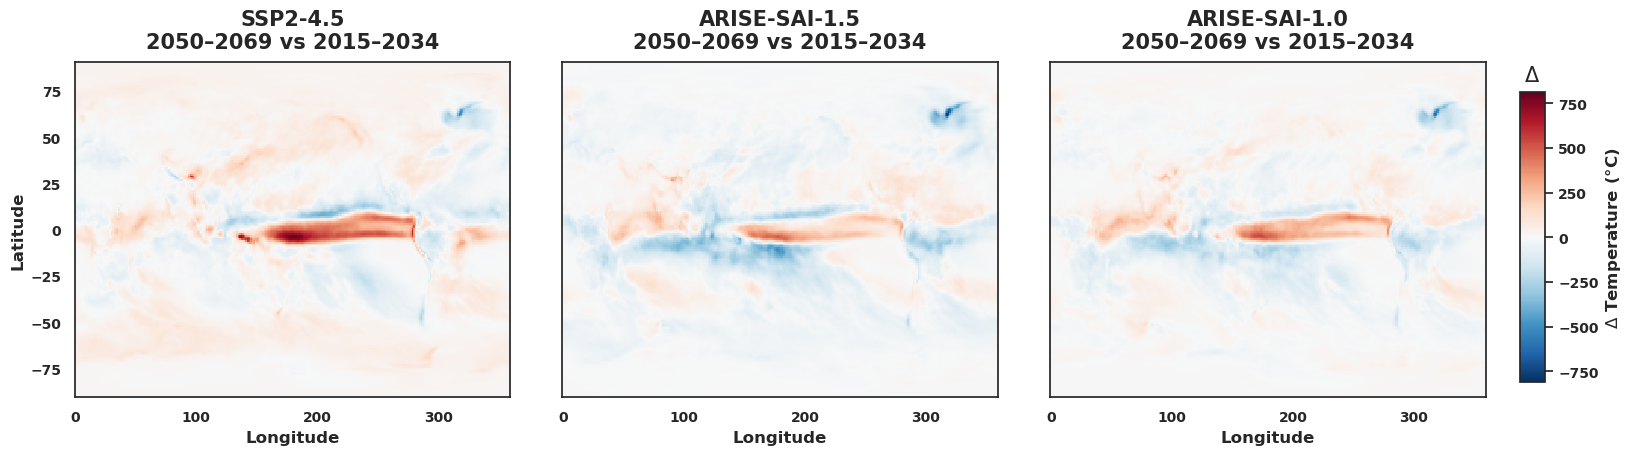

In [15]:
pres = xr.open_dataset("/mnt/research/nasabio/data/climate/L1/present/SSP245_PRECT.nc")
futssp = xr.open_dataset("/mnt/research/nasabio/data/climate/L1/future/SSP245_PRECT.nc")
futsai1 = xr.open_dataset("/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p0_PRECT.nc")
futsai15 = xr.open_dataset("/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p5_PRECT.nc")

futssp = futssp - pres
futsai1 = futsai1 - pres
futsai15 = futsai15 - pres


future_data = [
    futssp["PRCPTOT"],
    futsai1["PRCPTOT"],
    futsai15["PRCPTOT"]
]

future_titles = [
    "SSP2-4.5\n2050–2069 vs 2015–2034",
    "ARISE-SAI-1.5\n2050–2069 vs 2015–2034",
    "ARISE-SAI-1.0\n2050–2069 vs 2015–2034"
]

# Shared symmetric color scale centered at zero
delta_max = max(
    float(np.abs(d).max(skipna=True))
    for d in future_data
)

delta_vmin = -delta_max
delta_vmax = delta_max

fig, axs = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    sharex=True,
    sharey=True
)

for ax, d, title in zip(axs, future_data, future_titles):
    delta_image = d.plot(
        ax=ax,
        cmap="RdBu_r",
        vmin=delta_vmin,
        vmax=delta_vmax,
        add_colorbar=False
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel(
        "Longitude",
        fontsize=12,
        fontweight="bold"
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontsize(10)

axs[0].set_ylabel(
    "Latitude",
    fontsize=12,
    fontweight="bold"
)

axs[1].set_ylabel("")
axs[2].set_ylabel("")

# Make room on the right for one shared colorbar
fig.subplots_adjust(
    left=0.07,
    right=0.90,
    bottom=0.15,
    top=0.82,
    wspace=0.12
)

# Shared future colorbar
cbar_ax = fig.add_axes([
    0.92,
    0.18,
    0.015,
    0.58
])

delta_cbar = fig.colorbar(
    delta_image,
    cax=cbar_ax
)

delta_cbar.ax.set_title(
    r"$\Delta$",
    fontsize=15,
    fontweight="bold",
    pad=8
)

delta_cbar.set_label(
    r"$\Delta$ Temperature (°C)",
    fontsize=12,
    fontweight="bold"
)

for label in delta_cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

plt.show()

Shared PRCPTOT range: 11.23 to 6940.62


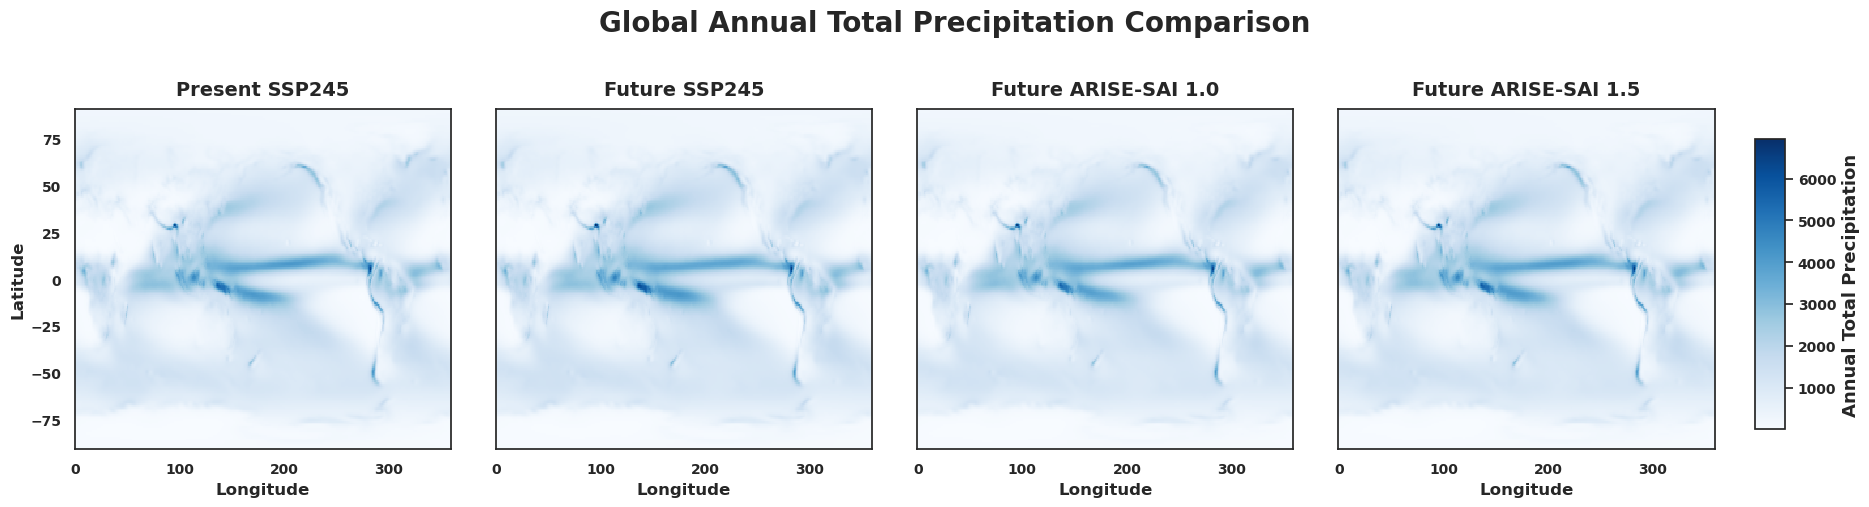

In [25]:
import xarray as xr
import matplotlib.pyplot as plt

# Open precipitation datasets
pres = xr.open_dataset(
    "/mnt/research/nasabio/data/climate/L1/present/SSP245_PRECT.nc"
)

futssp = xr.open_dataset(
    "/mnt/research/nasabio/data/climate/L1/future/SSP245_PRECT.nc"
)

futsai1 = xr.open_dataset(
    "/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p0_PRECT.nc"
)

futsai15 = xr.open_dataset(
    "/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p5_PRECT.nc"
)

# Select PRCPTOT
data = [
    pres["PRCPTOT"],
    futssp["PRCPTOT"],
    futsai1["PRCPTOT"],
    futsai15["PRCPTOT"]
]

titles = [
    "Present SSP245",
    "Future SSP245",
    "Future ARISE-SAI 1.0",
    "Future ARISE-SAI 1.5"
]

# Absolute minimum and maximum across all four datasets
vmin = min(float(d.min(skipna=True)) for d in data)
vmax = max(float(d.max(skipna=True)) for d in data)

print(f"Shared PRCPTOT range: {vmin:.2f} to {vmax:.2f}")

# Create four plots in one row
fig, axs = plt.subplots(
    1,
    4,
    figsize=(20, 5),
    sharex=True,
    sharey=True
)

for ax, d, title in zip(axs, data, titles):
    image = d.plot(
        ax=ax,
        cmap="Blues",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel(
        "Longitude",
        fontsize=12,
        fontweight="bold"
    )

    if ax is axs[0]:
        ax.set_ylabel(
            "Latitude",
            fontsize=12,
            fontweight="bold"
        )
    else:
        ax.set_ylabel("")

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_fontsize(10)

fig.suptitle(
    "Global Annual Total Precipitation Comparison",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

fig.subplots_adjust(
    left=0.06,
    right=0.88,
    bottom=0.14,
    top=0.82,
    wspace=0.12
)

# Shared colorbar
cbar_ax = fig.add_axes([0.90, 0.18, 0.015, 0.58])

cbar = fig.colorbar(
    image,
    cax=cbar_ax
)

cbar.set_label(
    "Annual Total Precipitation",
    fontsize=13,
    fontweight="bold"
)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(10)

plt.show()

EPSG:4269
EPSG:4269
EPSG:4269


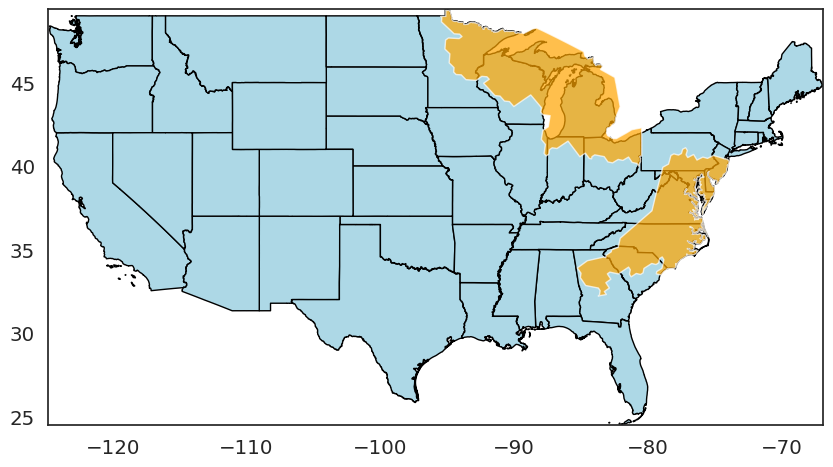

In [21]:
mask_path = "/mnt/home/f0113797/Documents/cb_2018_us_state_5m/cb_2018_us_state_5m.shp"
conus_states = gpd.read_file(mask_path)
mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)
great_lakes = NEON_sites[NEON_sites.domainName == "Great Lakes"]
mid_atlantic = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]


great_lakes = great_lakes.to_crs("EPSG:4269")
mid_atlantic = mid_atlantic.to_crs("EPSG:4269")
print(great_lakes.crs)
print(mid_atlantic.crs)
print(conus_states.crs)

fig, ax = plt.subplots(figsize=(10, 10))
conus_states.plot(ax=ax, color='lightblue', edgecolor='black')
great_lakes.plot(ax=ax, color = 'orange', alpha = 0.7)
mid_atlantic.plot(ax=ax, color = 'orange', alpha = 0.7)


# 3. Crop the visual area by setting coordinate boundaries (X=Longitude, Y=Latitude)
# Replace these numbers with your specific region coordinates
ax.set_xlim([-124.8, -66.9])  # Min and Max Longitude
ax.set_ylim([24.5, 49.4])    # Min and Max Latitude

plt.show()